# Titanic: Supervivencia y sus Determinantes
### Presentación de Datos — Práctica Obligatoria Visualización Avanzada
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Estilo global coherente para la presentación
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
})

df = pd.read_csv("titanic.csv")
df["child"] = df["age"] < 18
df["group"] = df.apply(
    lambda r: "Niño/a" if r["child"] else ("Mujer" if r["sex"] == "female" else "Hombre adulto"), axis=1
)
print(f"Dataset cargado: {df.shape[0]} pasajeros, {df.shape[1]} columnas")
df.head(3)


Dataset cargado: 891 pasajeros, 17 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,child,group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,False,Hombre adulto
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,False,Mujer
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,False,Mujer


---
## Slide 1 — El Titanic: una tragedia con altísima tasa de mortalidad


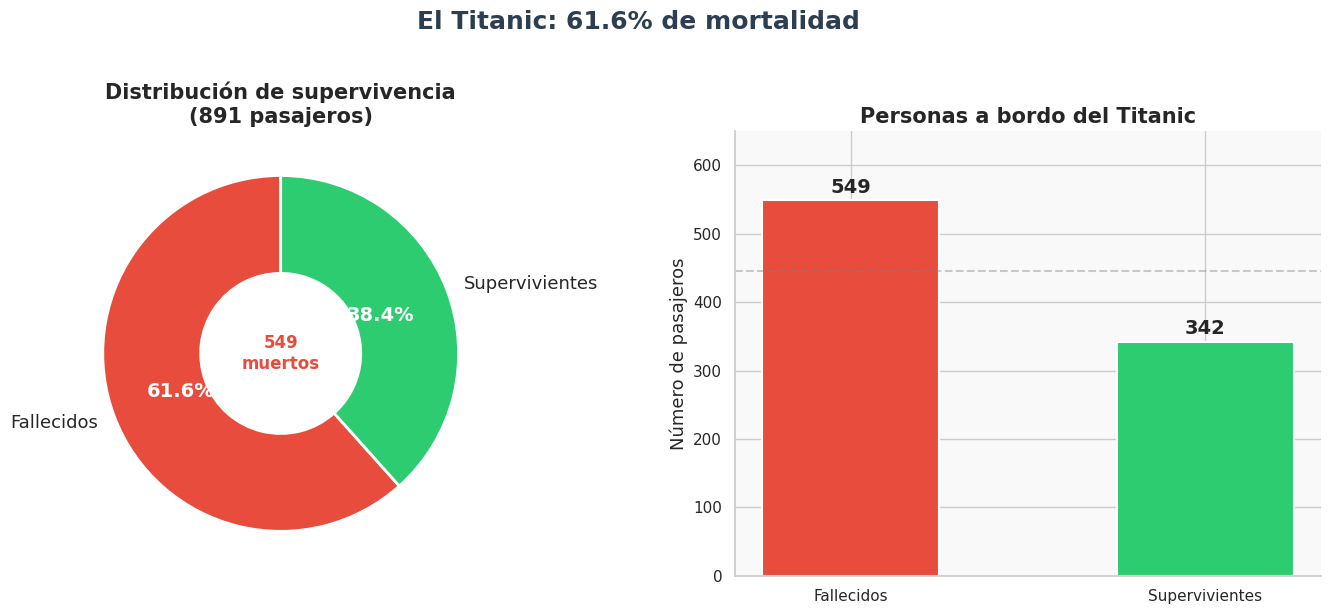

Total: 891 | Muertos: 549 (61.6%) | Supervivientes: 342 (38.4%)


In [2]:
total   = len(df)
surv    = df["survived"].sum()
dead    = total - surv

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Donut chart ----
ax = axes[0]
colors = ["#e74c3c", "#2ecc71"]
wedges, texts, autotexts = ax.pie(
    [dead, surv],
    labels=["Fallecidos", "Supervivientes"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=13),
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight("bold")
    at.set_color("white")
centre_circle = plt.Circle((0, 0), 0.35, fc="white")
ax.add_patch(centre_circle)
ax.set_title("Distribución de supervivencia\n(891 pasajeros)", fontsize=15, fontweight="bold")
ax.text(0, 0, f"{dead}\nmuertos", ha="center", va="center", fontsize=12, fontweight="bold", color="#e74c3c")

# ---- Barras absolutas ----
ax2 = axes[1]
bars = ax2.bar(["Fallecidos", "Supervivientes"], [dead, surv], color=colors, width=0.5,
               edgecolor="white", linewidth=1.5)
for bar, n in zip(bars, [dead, surv]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(n), ha="center", va="bottom", fontweight="bold", fontsize=14)
ax2.set_ylim(0, 650)
ax2.set_ylabel("Número de pasajeros")
ax2.set_title("Personas a bordo del Titanic", fontsize=15, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.axhline(y=total/2, color="gray", linestyle="--", alpha=0.4, label="50%")

plt.suptitle("El Titanic: 61.6% de mortalidad", fontsize=18, fontweight="bold", y=1.02, color="#2c3e50")
plt.tight_layout()
plt.savefig("slide1_mortalidad.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total: {total} | Muertos: {dead} ({dead/total:.1%}) | Supervivientes: {surv} ({surv/total:.1%})")


---
## Slide 2 — Los datos apoyan "las mujeres y los niños primero"


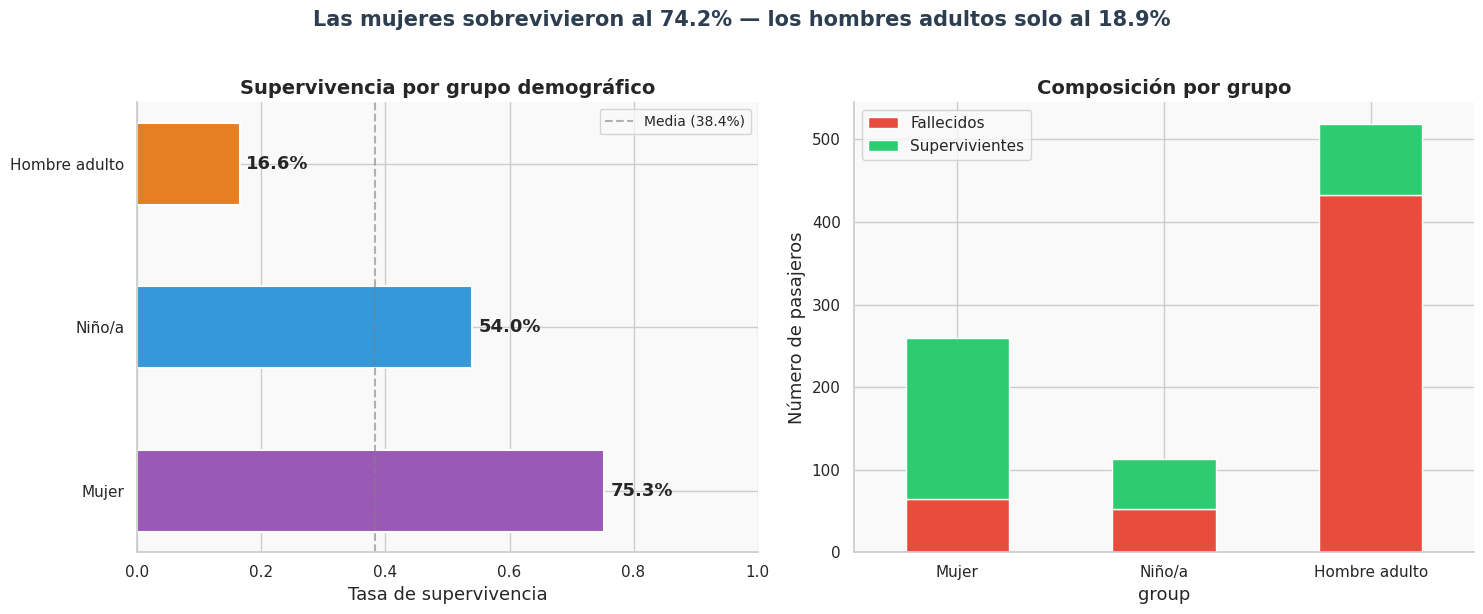

In [3]:
surv_group = df.groupby("group")["survived"].mean().reset_index()
surv_group.columns = ["Grupo", "Tasa de supervivencia"]
order = ["Mujer", "Niño/a", "Hombre adulto"]
surv_group = surv_group.set_index("Grupo").loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Barras por grupo ----
ax = axes[0]
palette = {"Mujer": "#9b59b6", "Niño/a": "#3498db", "Hombre adulto": "#e67e22"}
bars = ax.barh(surv_group["Grupo"], surv_group["Tasa de supervivencia"],
               color=[palette[g] for g in surv_group["Grupo"]],
               height=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, surv_group["Tasa de supervivencia"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.0)
ax.axvline(x=df["survived"].mean(), color="gray", linestyle="--", alpha=0.6, label=f"Media ({df['survived'].mean():.1%})")
ax.set_xlabel("Tasa de supervivencia")
ax.set_title("Supervivencia por grupo demográfico", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# ---- Stacked bar (supervivientes vs muertos por grupo) ----
ax2 = axes[1]
data_abs = df.groupby(["group","survived"]).size().unstack(fill_value=0)
data_abs = data_abs.loc[order]
data_abs.columns = ["Fallecidos", "Supervivientes"]
data_abs["Fallecidos"].plot(kind="bar", ax=ax2, color="#e74c3c", label="Fallecidos", width=0.5)
data_abs["Supervivientes"].plot(kind="bar", ax=ax2, color="#2ecc71", label="Supervivientes",
                                 bottom=data_abs["Fallecidos"], width=0.5)
ax2.set_xticklabels(order, rotation=0)
ax2.set_ylabel("Número de pasajeros")
ax2.set_title("Composición por grupo", fontsize=14, fontweight="bold")
ax2.legend()
ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("Las mujeres sobrevivieron al 74.2% — los hombres adultos solo al 18.9%",
             fontsize=15, fontweight="bold", y=1.02, color="#2c3e50")
plt.tight_layout()
plt.savefig("slide2_mujeres_ninos.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Slide 3 — La clase tuvo una influencia significativa en la supervivencia


/tmp/ipykernel_638/4231669433.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=class_fare, x="class", y="fare", order=class_order,


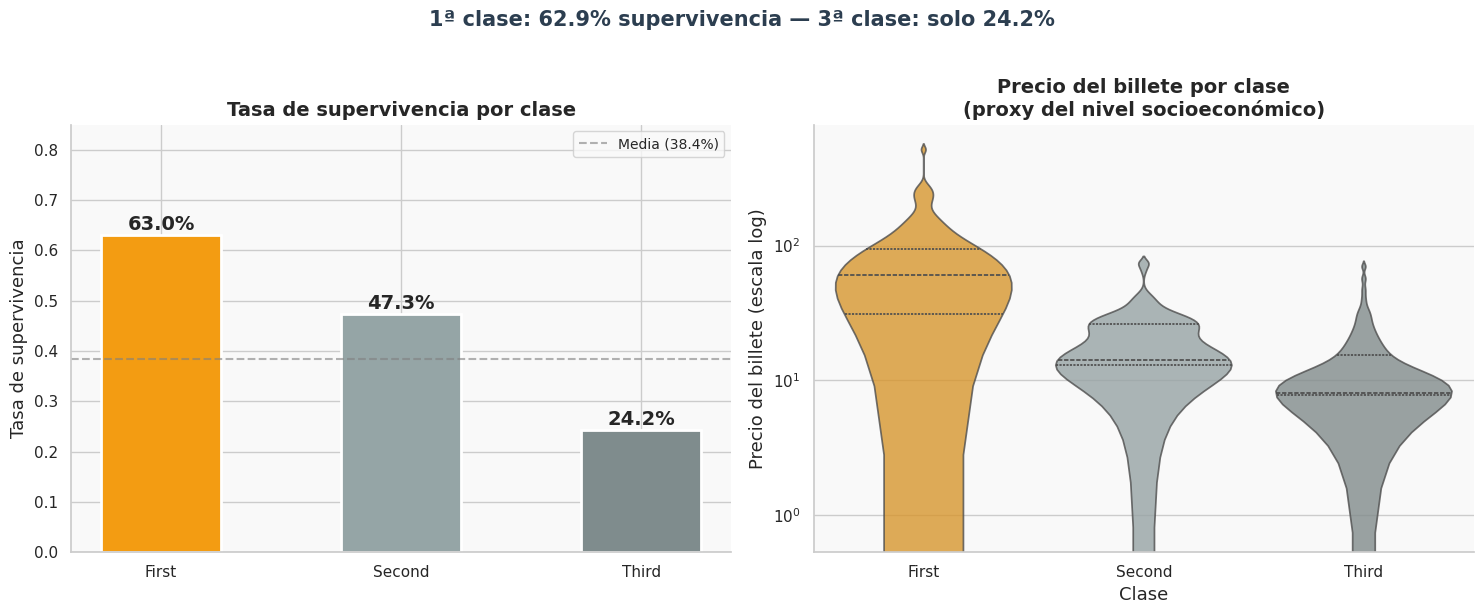

In [4]:
surv_class = df.groupby("class")["survived"].mean().reset_index()
surv_class.columns = ["Clase", "Tasa"]
class_order = ["First", "Second", "Third"]
surv_class = surv_class.set_index("Clase").loc[class_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Barras por clase ----
ax = axes[0]
c_palette = {"First": "#f39c12", "Second": "#95a5a6", "Third": "#7f8c8d"}
bars = ax.bar(surv_class["Clase"], surv_class["Tasa"],
              color=[c_palette[c] for c in surv_class["Clase"]],
              width=0.5, edgecolor="white", linewidth=2)
for bar, val in zip(bars, surv_class["Tasa"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=14, fontweight="bold")
ax.axhline(y=df["survived"].mean(), color="gray", linestyle="--", alpha=0.6, label=f"Media ({df['survived'].mean():.1%})")
ax.set_ylim(0, 0.85)
ax.set_ylabel("Tasa de supervivencia")
ax.set_title("Tasa de supervivencia por clase", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# ---- Violin / strip por clase ----
ax2 = axes[1]
class_fare = df.dropna(subset=["fare"])
sns.violinplot(data=class_fare, x="class", y="fare", order=class_order,
               palette=c_palette, ax=ax2, inner="quartile", alpha=0.8)
ax2.set_yscale("log")
ax2.set_xlabel("Clase")
ax2.set_ylabel("Precio del billete (escala log)")
ax2.set_title("Precio del billete por clase\n(proxy del nivel socioeconómico)", fontsize=14, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("1ª clase: 62.9% supervivencia — 3ª clase: solo 24.2%",
             fontsize=15, fontweight="bold", y=1.02, color="#2c3e50")
plt.tight_layout()
plt.savefig("slide3_clase.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Slide 4 — La clase explica las diferencias dentro de mujeres y niños


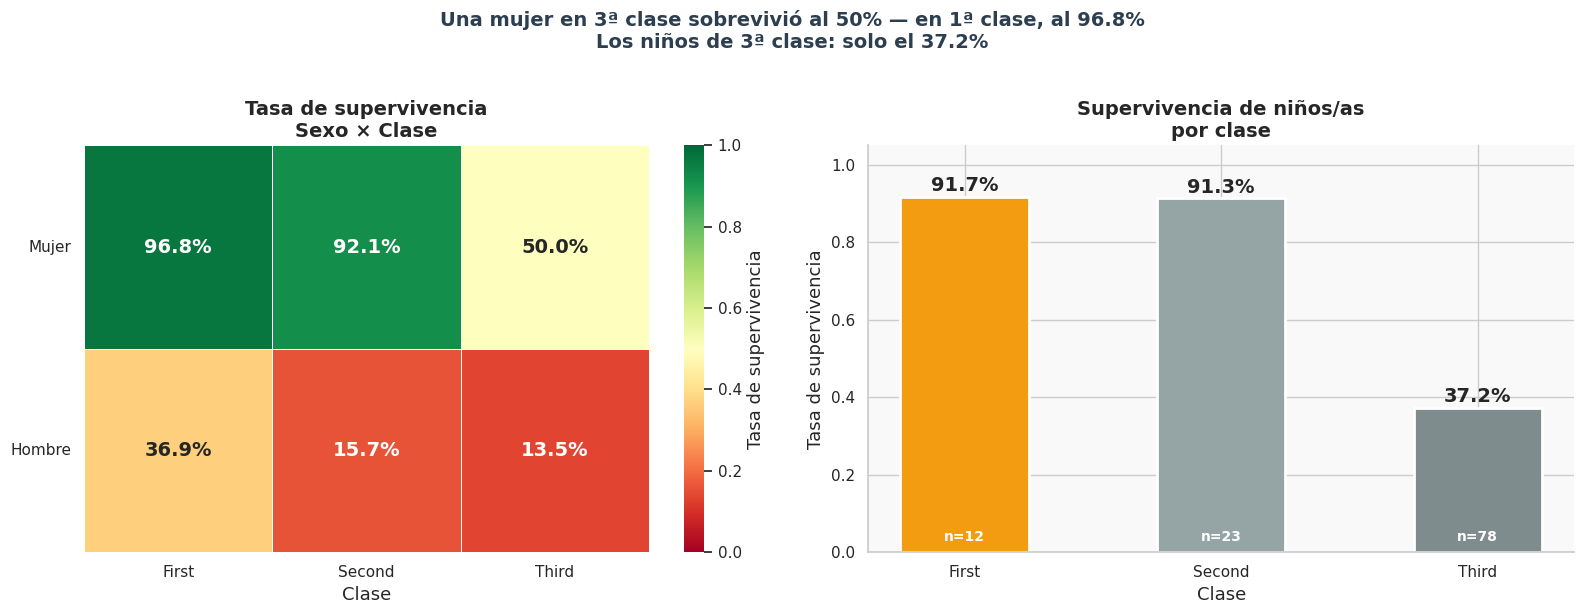

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Heatmap mujeres por clase ----
pivot_sex = df.groupby(["sex","class"])["survived"].mean().unstack()
pivot_sex = pivot_sex[class_order]
pivot_sex.index = ["Mujer", "Hombre"]

ax = axes[0]
sns.heatmap(pivot_sex, annot=True, fmt=".1%", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"},
            cbar_kws={"label": "Tasa de supervivencia"})
ax.set_title("Tasa de supervivencia\nSexo × Clase", fontsize=14, fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ---- Barras agrupadas niños por clase ----
children = df[df["child"] == True]
surv_children = children.groupby("class")["survived"].mean().reset_index()
surv_children = surv_children.set_index("class").loc[class_order].reset_index()

ax2 = axes[1]
c_palette = {"First": "#f39c12", "Second": "#95a5a6", "Third": "#7f8c8d"}
bars = ax2.bar(surv_children["class"], surv_children["survived"],
               color=[c_palette[c] for c in surv_children["class"]],
               width=0.5, edgecolor="white", linewidth=2)
for bar, val in zip(bars, surv_children["survived"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{val:.1%}", ha="center", fontsize=14, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Tasa de supervivencia")
ax2.set_xlabel("Clase")
ax2.set_title("Supervivencia de niños/as\npor clase", fontsize=14, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)

# Añadir etiqueta de n
for bar, cls in zip(bars, class_order):
    n = len(children[children["class"] == cls])
    ax2.text(bar.get_x() + bar.get_width()/2, 0.03,
             f"n={n}", ha="center", fontsize=10, color="white", fontweight="bold")

plt.suptitle("Una mujer en 3ª clase sobrevivió al 50% — en 1ª clase, al 96.8%\nLos niños de 3ª clase: solo el 37.2%",
             fontsize=14, fontweight="bold", y=1.02, color="#2c3e50")
plt.tight_layout()
plt.savefig("slide4_clase_genero.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Slide 5 — El puerto de embarque refleja el tipo de pasaje, no el puerto en sí


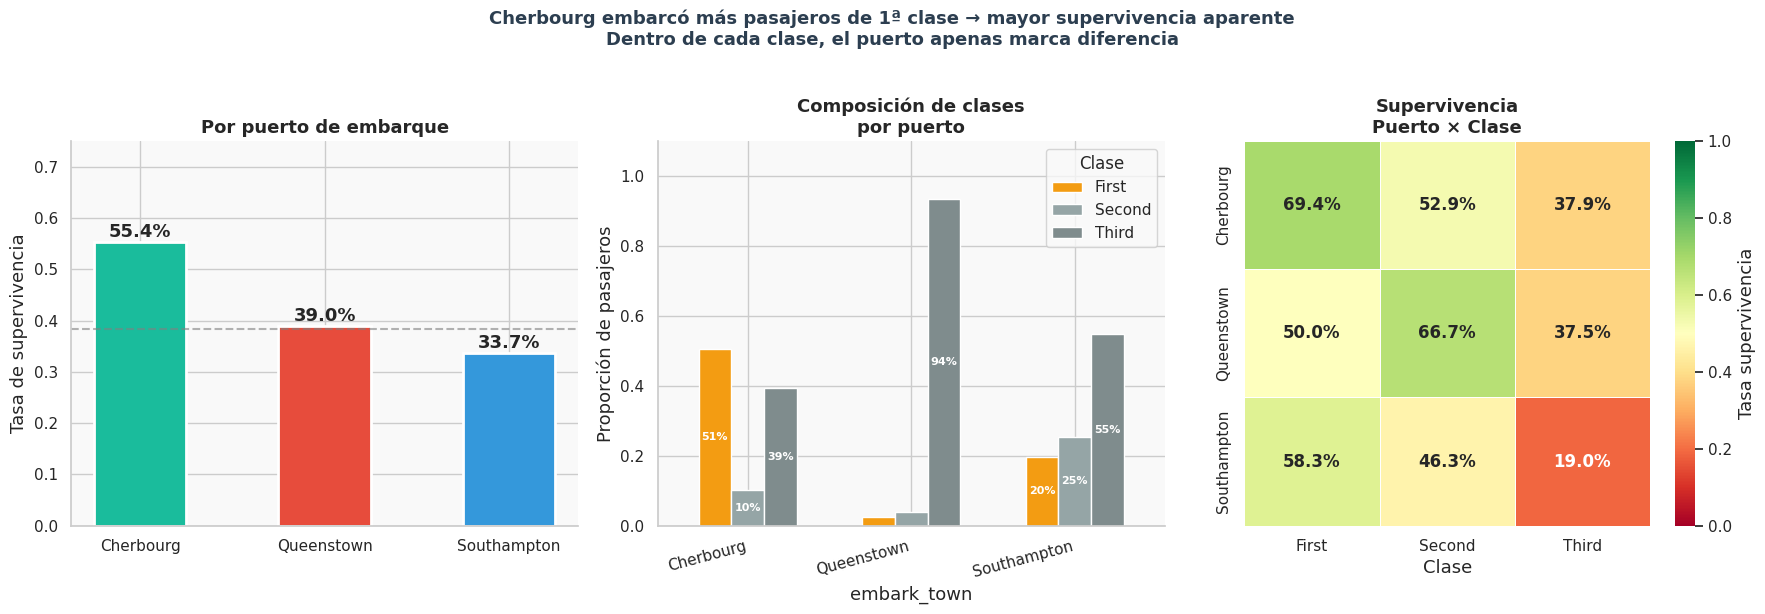

In [6]:
df_port = df.dropna(subset=["embark_town"])
port_order = ["Cherbourg", "Queenstown", "Southampton"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- Barras supervivencia por puerto ----
ax = axes[0]
surv_port = df_port.groupby("embark_town")["survived"].mean().loc[port_order]
p_palette = {"Cherbourg": "#1abc9c", "Queenstown": "#e74c3c", "Southampton": "#3498db"}
bars = ax.bar(surv_port.index, surv_port.values,
              color=[p_palette[p] for p in surv_port.index],
              width=0.5, edgecolor="white", linewidth=2)
for bar, val in zip(bars, surv_port.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")
ax.axhline(y=df["survived"].mean(), color="gray", linestyle="--", alpha=0.6)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Tasa de supervivencia")
ax.set_title("Por puerto de embarque", fontsize=13, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

# ---- Composición de clases por puerto ----
ax2 = axes[1]
class_by_port = df_port.groupby(["embark_town","class"]).size().unstack(fill_value=0)
class_by_port = class_by_port.loc[port_order, class_order]
class_by_port_pct = class_by_port.div(class_by_port.sum(axis=1), axis=0)
class_colors = ["#f39c12", "#95a5a6", "#7f8c8d"]
class_by_port_pct.plot(kind="bar", ax=ax2, color=class_colors, width=0.6, edgecolor="white")
ax2.set_xticklabels(port_order, rotation=15, ha="right")
ax2.set_ylabel("Proporción de pasajeros")
ax2.set_ylim(0, 1.1)
ax2.set_title("Composición de clases\npor puerto", fontsize=13, fontweight="bold")
ax2.legend(title="Clase", labels=class_order)
ax2.spines[["top","right"]].set_visible(False)
for p in ax2.patches:
    h = p.get_height()
    if h > 0.05:
        ax2.text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                 f"{h:.0%}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# ---- Heatmap puerto × clase ----
ax3 = axes[2]
pivot_port = df_port.groupby(["embark_town","class"])["survived"].mean().unstack()
pivot_port = pivot_port.loc[port_order, class_order]
sns.heatmap(pivot_port, annot=True, fmt=".1%", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax3, linewidths=0.5, linecolor="white",
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"label": "Tasa supervivencia"})
ax3.set_title("Supervivencia\nPuerto × Clase", fontsize=13, fontweight="bold")
ax3.set_xlabel("Clase")
ax3.set_ylabel("")

plt.suptitle("Cherbourg embarcó más pasajeros de 1ª clase → mayor supervivencia aparente\n"
             "Dentro de cada clase, el puerto apenas marca diferencia",
             fontsize=13, fontweight="bold", y=1.02, color="#2c3e50")
plt.tight_layout()
plt.savefig("slide5_puerto.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Conclusión narrativa

| Slide | Mensaje clave | Dato principal |
|-------|--------------|----------------|
| 1 | Alta tasa de mortalidad | 61.6% fallecidos (549/891) |
| 2 | Mujeres y niños primero | Mujeres 74.2% · Niños 53.9% · Hombres adultos 18.9% |
| 3 | La clase importó mucho | 1ª: 62.9% · 2ª: 47.3% · 3ª: 24.2% |
| 4 | La clase explica las diferencias dentro de género | Mujer 1ª: 96.8% vs Mujer 3ª: 50.0% |
| 5 | El puerto refleja la clase embarcada | Dentro de cada clase, el puerto no es determinante |
